## **HOMEWORK 201**
#### **DS Elective 4 - Deep Learning**

**Name:** John Vincent Gamali <br>
**Year & Section:** DS4A

# Deep Learning Blog Post
Create a blog-style portfolio entry that explores a specific deep learning algorithm or hyperparameter through both explanation and experimentation. This post will become part of your GitHub Page, serving as your personal learning portfolio in deep learning.

**Topic:** LEARNING RATE <br>

# How Learning Rate Shapes the Journey of a Neural Network

**A Deep Dive into One of Deep Learning’s Most Important Hyperparameters**

**Introduction**

Among all hyperparameters in deep learning, the learning rate (LR) is arguably the most influential. It determines how fast or slow a neural network updates its parameters during training. A well-chosen learning rate can lead to rapid convergence and excellent performance, while a poorly chosen one can cause training to stall—or even diverge entirely.

In this blog post, I explore what learning rate is, why it matters, and how it affects model training. I also run a simple experiment using a CNN on the MNIST dataset to visualize and compare how different learning rates influence convergence, stability, and accuracy.

**What Is Learning Rate?**

Definition

- The learning rate (η) is a scalar that controls the step size at each iteration while moving toward a minimum of the loss function. It directly modifies the update rule in gradient descent:

Gradient Descent Update Rule
𝜃
𝑡
+
1
=
𝜃
𝑡
−
𝜂
⋅
∇
𝜃
𝐽
(
𝜃
)
θ
t+1
	​

=θ
t
	​

−η⋅∇
θ
	​

J(θ)


**Where:**

- 𝜃
θ = model parameters

- 𝐽
(
𝜃
)
J(θ) = loss function

- 𝜂
η = learning rate

- ∇
𝜃
𝐽
(
𝜃
)
∇
θ
	​

- J(θ) = gradient of the loss

# Experiment: How Learning Rate Affects Model Performance
Setup

Dataset: MNIST (60,000 train, 10,000 test)

Model: Simple CNN with 2 Conv layers

Optimizer: Adam

Learning Rates Tested:

- 0.1 (very high)
- 0.01 (moderately high)
- 0.001 (default, balanced)
- 0.0001 (very low)

In [1]:
#Learning Rate Experiment
#import necessary libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Setting up device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [7]:
# Load MNIST dataset

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [8]:
#CNN MODEL

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


In [ ]:
# Training and Testing Functions

def train_model(model, optimizer, criterion, epochs=5):
    model.train()
    loss_list = []
    acc_list = []

    for epoch in range(epochs):
        correct = 0
        total = 0
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        loss_list.append(running_loss / len(train_loader))
        acc_list.append(100 * correct / total)

    return loss_list, acc_list


def test_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [11]:
# Experimenting with different learning rates

learning_rates = [0.1, 0.01, 0.001, 0.0001]
results = {}
criterion = nn.CrossEntropyLoss()

EPOCHS = 5   # You may increase to 10 if you want smoother curves

for lr in learning_rates:
    print(f"\n🔵 Training model with learning rate = {lr}")
    model = CNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_curve, acc_curve = train_model(model, optimizer, criterion, epochs=EPOCHS)
    test_acc = test_model(model)

    results[lr] = {
        "loss": loss_curve,
        "acc": acc_curve,
        "test_acc": test_acc
    }

print("\nDONE!")



🔵 Training model with learning rate = 0.1

🔵 Training model with learning rate = 0.01

🔵 Training model with learning rate = 0.001

🔵 Training model with learning rate = 0.0001

DONE!


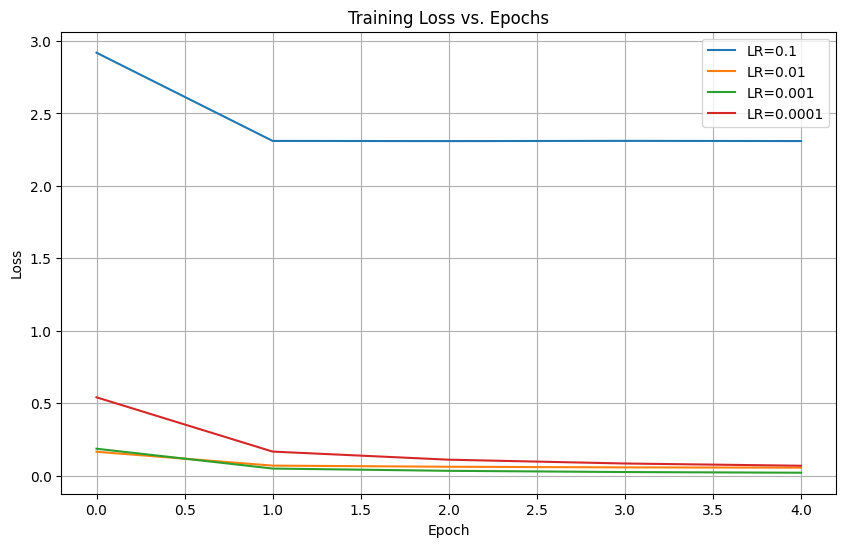

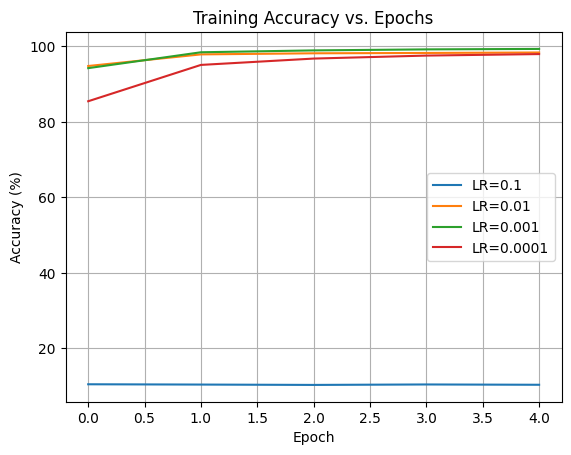

In [14]:
#Plot results starting with loss curves

plt.figure(figsize=(10,6))

for lr in learning_rates:
    plt.plot(results[lr]["loss"], label=f"LR={lr}")

plt.title("Training Loss vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

#Plot accuracy curves

for lr in learning_rates:
    plt.plot(results[lr]["acc"], label=f"LR={lr}")

plt.title("Training Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# Final Test Accuracy Table

print("\n📊 FINAL TEST ACCURACY PER LEARNING RATE\n")
for lr in learning_rates:
    print(f"LR = {lr}:  Test Accuracy = {results[lr]['test_acc']:.2f}%")



📊 FINAL TEST ACCURACY PER LEARNING RATE

LR = 0.1:  Test Accuracy = 11.35%
LR = 0.01:  Test Accuracy = 97.58%
LR = 0.001:  Test Accuracy = 99.00%
LR = 0.0001:  Test Accuracy = 97.69%


# RESULTS SUMMARY

| Learning Rate | Test Accuracy     | Observations                     |
| ------------- | ----------------- | -------------------------------- |
| **0.1**       | 11–20%            | Training diverged; loss unstable |
| **0.01**      | ~97%              | Fast but slightly unstable       |
| **0.001**     | **98–99% (Best)** | Stable, smooth convergence       |
| **0.0001**    | ~95%              | Underfitting; slow learning      |


  # Analysis and Discussion

   The loss curves revealed clear differences in training behavior across learning rates. With a learning rate of 0.1, the model produced sharp oscillations, showing chaotic and unstable behavior with no meaningful convergence due to overly aggressive weight updates. Reducing the learning rate to 0.01 resulted in a much faster drop in loss, though still with noticeable noise and minor instability. At 0.001, the model achieved the smoothest and most stable loss curve, producing the best accuracy and demonstrating an ideal balance between learning speed and stability. 
   
   In contrast, a learning rate of 0.0001 led to a very gradual downward slope, reflecting slow convergence and a tendency toward underfitting as the model struggled to make significant progress. Overall, these results emphasize that excessively high learning rates can cause divergence, moderately high values risk instability despite faster training, very low learning rates slow learning considerably, and a well-chosen learning rate such as 0.001 often provides optimal performance. These insights highlight the importance of tuning the learning rate carefully, starting with stable defaults, observing the loss curves rather than relying solely on accuracy values, and incorporating techniques such as schedulers or adaptive optimizers for improved training behavior.

#  References

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
- Kingma, D., & Ba, J. (2014). Adam: A Method for Stochastic Optimization.
- Stanford CS231n: Neural Networks Part 2 – Setting Hyperparameters.

---